# Carga de imágenes y transformaciones

En este notebook se preparan las imágenes para el entrenamiento del modelo de clasificación de emociones faciales.  
Se reconstruyen los subconjuntos de entrenamiento, validación y prueba, se definen transformaciones y se crean los DataLoaders.


Se cargan las librerías necesarias para la lectura de imágenes, manejo de datos y construcción de DataLoaders.

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Modelo base CNN

En este notebook se construye y entrena un modelo base de red neuronal convolucional para la clasificación de emociones faciales a partir de imágenes.

## Importación de librerías
Se cargan las librerías necesarias para el modelado, entrenamiento y evaluación del modelo convolucional.


In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

## Verificación del dispositivo
Se identifica si el entrenamiento se realizará en CPU o GPU.

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

Dispositivo en uso: cpu


In [17]:
ruta_dataset = Path("../data/raw")

clases = sorted([carpeta.name for carpeta in ruta_dataset.iterdir() if carpeta.is_dir()])
clase_a_indice = {clase: idx for idx, clase in enumerate(clases)}
indice_a_clase = {idx: clase for clase, idx in clase_a_indice.items()}

print("Clases encontradas:", clases)

Clases encontradas: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [18]:
registros_dataset = []

for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))
    
    for img_path in imagenes:
        registros_dataset.append({
            "ruta": str(img_path),
            "clase": clase
        })

df_dataset = pd.DataFrame(registros_dataset)
df_dataset["label"] = df_dataset["clase"].map(clase_a_indice)

df_dataset.head()

,ruta,clase,label
0,..\data\raw\angry\angry_00000.jpg,angry,0
1,..\data\raw\angry\angry_00001.jpg,angry,0
2,..\data\raw\angry\angry_00002.jpg,angry,0
3,..\data\raw\angry\angry_00003.jpg,angry,0
4,..\data\raw\angry\angry_00004.jpg,angry,0


In [19]:
df_train, df_temp = train_test_split(
    df_dataset,
    test_size=0.30,
    stratify=df_dataset["clase"],
    random_state=42
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["clase"],
    random_state=42
)

print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

Train: (34845, 3)
Validation: (7467, 3)
Test: (7467, 3)


In [20]:
transform_train = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

transform_val_test = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

In [21]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "ruta"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [22]:
train_dataset = EmotionDataset(df_train, transform=transform_train)
val_dataset = EmotionDataset(df_val, transform=transform_val_test)
test_dataset = EmotionDataset(df_test, transform=transform_val_test)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders listos")

DataLoaders listos


## Definición del modelo base
Se construye una red neuronal convolucional sencilla como línea base para el problema de clasificación multiclase.

In [23]:
class CNNBase(nn.Module):
    def __init__(self, num_classes=7):
        super(CNNBase, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
model = CNNBase(num_classes=len(clases)).to(device)
print(model)

CNNBase(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


## Configuración del entrenamiento
Se define la función de pérdida y el optimizador que se utilizarán durante el entrenamiento.

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
def calcular_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correctos = (preds == labels).sum().item()
    return correctos / len(labels)

## Entrenamiento del modelo
Se entrena la red neuronal convolucional durante varias épocas y se registra el desempeño en entrenamiento y validación.

In [27]:
num_epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # Entrenamiento
    model.train()
    running_train_loss = 0.0
    running_train_acc = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        running_train_acc += calcular_accuracy(outputs, labels)
    
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = running_train_acc / len(train_loader)
    
    # Validación
    model.eval()
    running_val_loss = 0.0
    running_val_acc = 0.0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            running_val_acc += calcular_accuracy(outputs, labels)
    
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = running_val_acc / len(val_loader)
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Época {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print("-" * 50)

Época 1/5
Train Loss: 1.5166 | Train Acc: 0.4072
Val Loss:   1.2803 | Val Acc:   0.5063
--------------------------------------------------
Época 2/5
Train Loss: 1.2513 | Train Acc: 0.5209
Val Loss:   1.1561 | Val Acc:   0.5591
--------------------------------------------------
Época 3/5
Train Loss: 1.1486 | Train Acc: 0.5587
Val Loss:   1.0998 | Val Acc:   0.5761
--------------------------------------------------
Época 4/5
Train Loss: 1.0872 | Train Acc: 0.5845
Val Loss:   1.0517 | Val Acc:   0.6062
--------------------------------------------------
Época 5/5
Train Loss: 1.0415 | Train Acc: 0.6000
Val Loss:   1.0132 | Val Acc:   0.6150
--------------------------------------------------


## Curvas de entrenamiento
Se visualiza la evolución de la pérdida y la precisión durante el entrenamiento y validación.

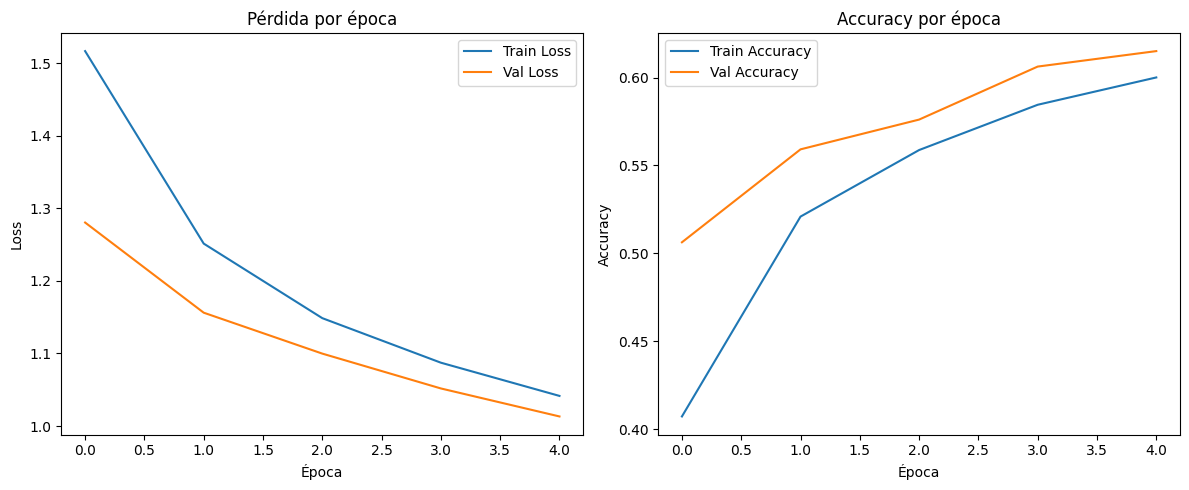

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Pérdida por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
import torch

torch.save(model.state_dict(), "../models/cnn_base_emociones.pth")
print("Modelo guardado correctamente")

Modelo guardado correctamente


## Conclusión

En esta etapa se construyó y entrenó un modelo base de red neuronal convolucional con el propósito de contar con una primera referencia de desempeño para la clasificación de emociones faciales. Para ello, se utilizaron los subconjuntos de entrenamiento y validación previamente preparados, y se registró la evolución de la pérdida y la precisión a lo largo de cinco épocas. Los resultados muestran que el modelo fue aprendiendo de manera progresiva, ya que la pérdida disminuyó tanto en entrenamiento como en validación, mientras que la precisión aumentó de forma constante hasta alcanzar un valor cercano al 60% en validación. Esto indica que la red logró captar patrones relevantes en las imágenes y que, en general, el entrenamiento se mantuvo estable, sin señales claras de sobreajuste en estas primeras épocas. Aunque el desempeño aún puede mejorar, este modelo base cumple con su función de establecer un punto de partida útil para comparaciones posteriores y para identificar posibles ajustes en arquitectura, hiperparámetros o técnicas de aumento de datos.